# Real fetal MRI segmentation and growth-chart demonstration

This notebook uses the real 30-week fetal T2 atlas example distributed by FetalSynthSeg, not a synthetic phantom. The image and manual label map originate from the CC0 IMAGINE Fetal T2-weighted MRI Atlas (doi:10.7910/DVN/WE9JVR). The automatic labels are produced by the official FetalSynthSeg checkpoint. Results are research aids, not diagnoses.

In [1]:
from pathlib import Path
import json
from IPython.display import Image, display
from fetal_brain_growth.case_report import save_case_report
from fetal_brain_growth.charts import save_growth_chart
from fetal_brain_growth.radiology import save_radiology_figure
from fetal_brain_growth.references import build_table_curves, score_against_curves
from fetal_brain_growth.validation import tissue_dice
from fetal_brain_growth.volumetry import measure_segmentation
from fetal_brain_growth.segmentation import segment_image

In [2]:
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
EXAMPLE = ROOT/'third_party/FetalSynthSeg/data/sub-sta30/anat'
IMAGE_PATH = EXAMPLE/'sub-sta30_rec-irtk_T2w.nii.gz'
MANUAL_PATH = EXAMPLE/'sub-sta30_rec-irtk_T2w_dseg.nii.gz'
CHECKPOINT = ROOT/'models/KISPI-all_fss.ckpt'
OUT = ROOT/'demo_outputs/real_example'; OUT.mkdir(parents=True, exist_ok=True)
PREDICTED_PATH = OUT/'sub-sta30_fetalsynthseg.nii.gz'
missing = [p for p in (IMAGE_PATH, MANUAL_PATH, CHECKPOINT) if not p.exists()]
if missing:
    raise FileNotFoundError('Run ./scripts/install_fetalsynthseg.sh --accept-license first. Missing: ' + ', '.join(map(str, missing)))
print('Real example:', IMAGE_PATH.name, '• gestational age 30 weeks')

Real example: sub-sta30_rec-irtk_T2w.nii.gz • gestational age 30 weeks


## 1. Run FetalSynthSeg and inspect standard orientation

The wrapper reproduces the official 0.5-mm preprocessing and U-Net, verifies the checkpoint SHA-256 before deserialization, restores labels to native geometry, and records provenance.

Using previously generated prediction: sub-sta30_fetalsynthseg.nii.gz


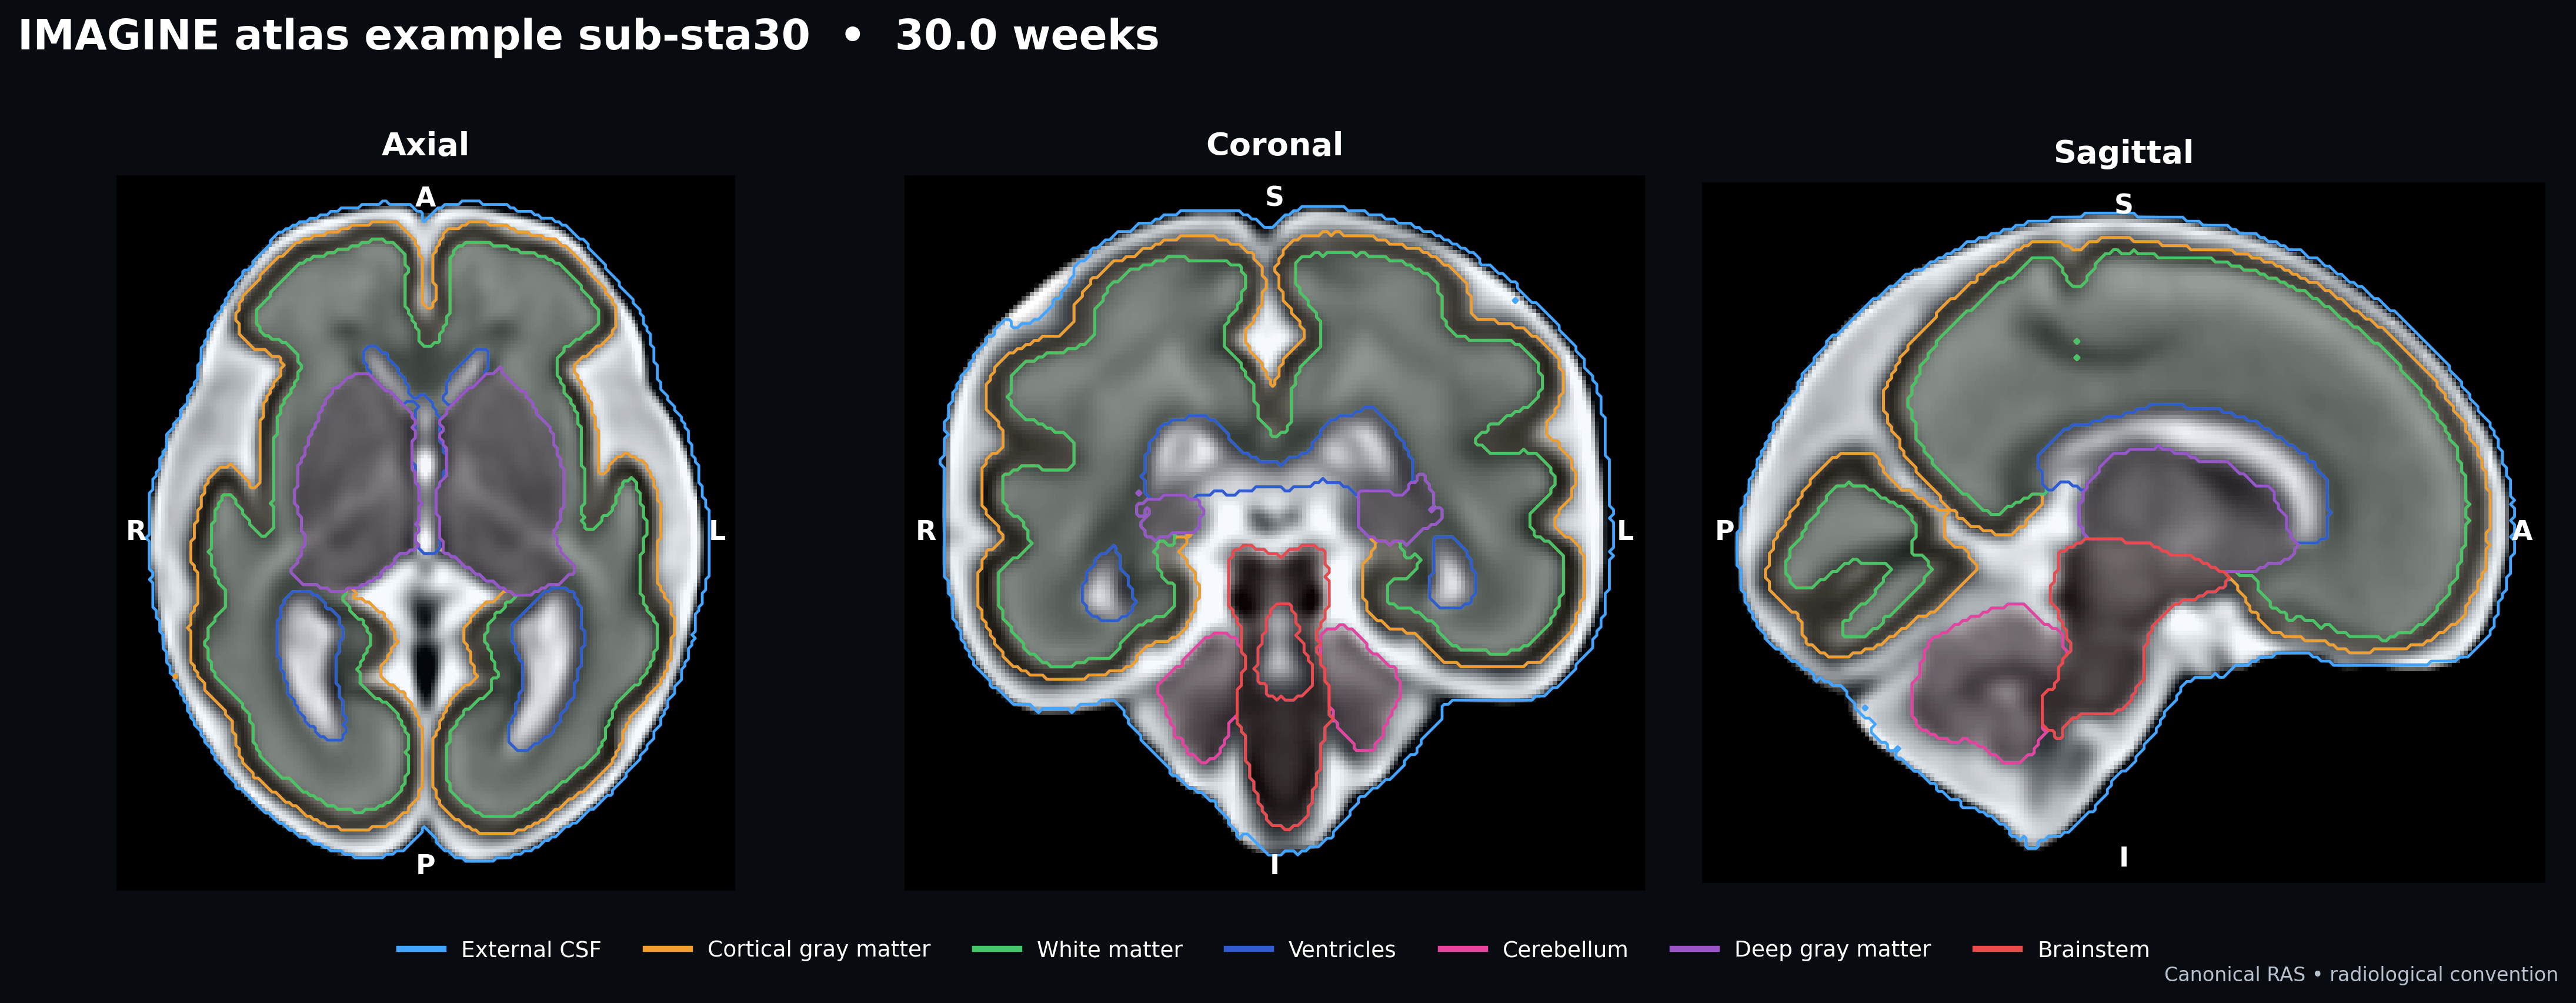

In [3]:
if not PREDICTED_PATH.exists():
    metadata = segment_image(IMAGE_PATH, PREDICTED_PATH, CHECKPOINT, device_name='auto', metadata_path=OUT/'segmentation_provenance.json')
    public_keys = ('checkpoint_sha256','official_repository','official_commit','device','elapsed_seconds','torch_version','monai_version','intended_use')
    print(json.dumps({key: metadata[key] for key in public_keys}, indent=2))
else:
    print('Using previously generated prediction:', PREDICTED_PATH.name)
qc_figure = save_radiology_figure(IMAGE_PATH, PREDICTED_PATH, OUT/'segmentation_qc.png', subject_id='IMAGINE atlas example sub-sta30', gestational_age_weeks=30.0, fill_alpha=0.05)
display(Image(filename=str(qc_figure), width=1200))

The three panels are reoriented to canonical RAS and shown in radiological convention. Contours preserve the underlying T2 anatomy; patient right appears on image left in axial and coronal views.

## 2. One-case execution validation against the supplied manual labels

Dice here checks model loading, preprocessing, inverse resampling, geometry, and label identity on one real labeled image. It is not a cohort-level accuracy claim.

In [4]:
dice = tissue_dice(PREDICTED_PATH, MANUAL_PATH)
display(dice[['label','tissue','dice','predicted_voxels','manual_voxels']].style.format({'dice':'{:.3f}'}))
print(f"Mean tissue Dice: {dice.dice.mean():.3f}; range {dice.dice.min():.3f}–{dice.dice.max():.3f}")

,label,tissue,dice,predicted_voxels,manual_voxels
0,1,External CSF,0.871,760385,766606
1,2,Cortical gray matter,0.800,403890,510341
2,3,White matter,0.910,785310,739926
3,4,Ventricles,0.685,86836,48144
4,5,Cerebellum,0.925,64346,61194
5,6,Deep gray matter,0.853,87843,90029
6,7,Brainstem,0.811,40887,42726


Mean tissue Dice: 0.836; range 0.685–0.925


## 3. Affine-aware tissue and aggregate volumes

Each volume is `voxel count × abs(det(affine[:3,:3])) / 1000` mL. Native FetalSynthSeg tissues and definition-aware literature aggregates remain separate.

In [5]:
tissues, aggregates, qc = measure_segmentation(PREDICTED_PATH, subject_id='sub-sta30', gestational_age_weeks=30.0)
display(tissues[['label','region','volume_ml']].style.format({'volume_ml':'{:.2f}'}))
display(aggregates[['region','labels','volume_ml']].style.format({'volume_ml':'{:.2f}'}))
qc

,label,region,volume_ml
0,1,external_csf,95.05
1,2,cortical_gray_matter,50.49
2,3,white_matter,98.16
3,4,ventricles,10.85
4,5,cerebellum,8.04
5,6,deep_gray_matter,10.98
6,7,brainstem,5.11


,region,labels,volume_ml
0,total_brain,2+3+5+6+7,172.78
1,intracranial_volume,1+2+3+4+5+6+7,278.69
2,cortical_gray_matter,2,50.49
3,subcortical_brain_tissue,3+6,109.14
4,external_csf,1,95.05
5,ventricles,4,10.85
6,cerebellum,5,8.04
7,brainstem,7,5.11


{'foreground_voxels': 2229497,
 'connected_components': 18,
 'largest_component_fraction': 0.9999869925817348,
 'touches_image_boundary': False,
 'missing_labels': [],
 'warnings': [],
 'subject_id': 'sub-sta30',
 'shape': [256, 256, 256],
 'voxel_volume_ml': 0.00012500000000000003,
 'orientation': 'RAS'}

## 4. Position the real case on multiple quantiles

P3/P10/P25/P50/P75/P90/P97 are reconstructed from Ren 2022 weekly mean/SD under an explicit Normal approximation. Only total brain, intracranial volume, external CSF, and cerebellum are definition-aligned enough for automated research flags.

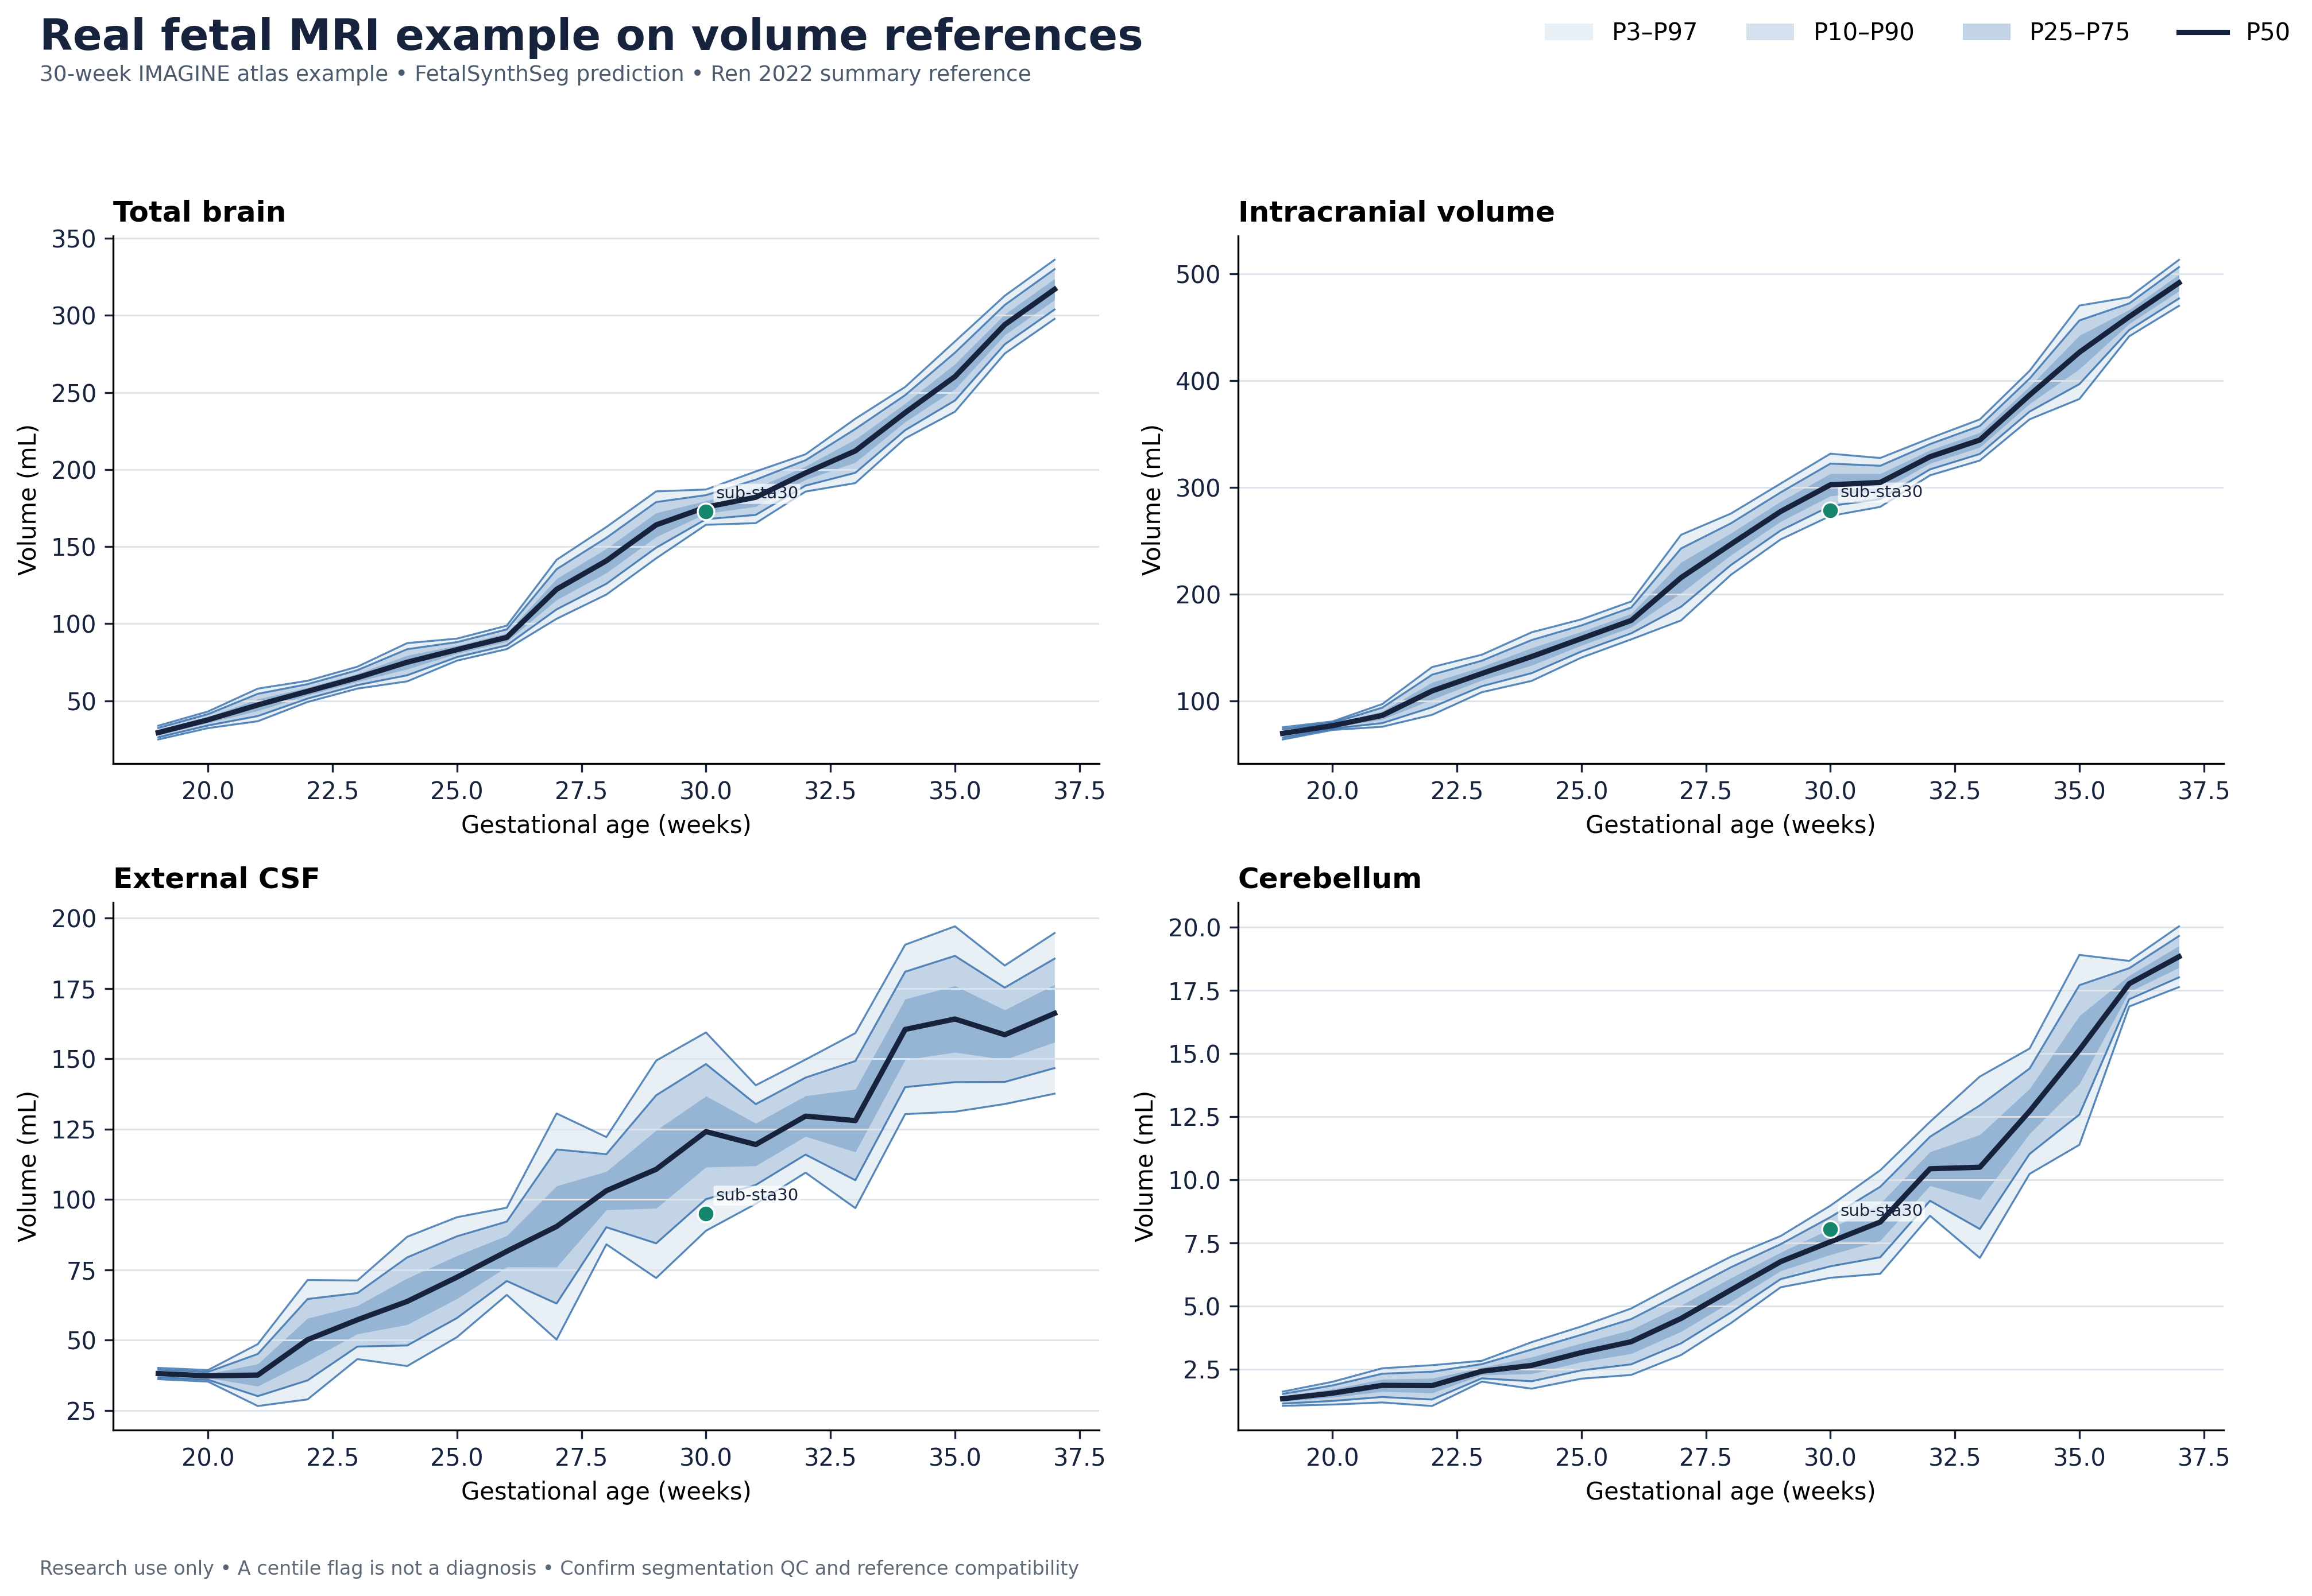

,region,volume_ml,estimated_percentile_bounded,status,interpretation_note
0,total_brain,172.784500,32.864259,within_reference_interval,Definition-aligned research comparison; local ...
1,intracranial_volume,278.687125,7.035577,within_reference_interval,Definition-aligned research comparison; local ...
2,cortical_gray_matter,50.486250,97.000000,comparison_only_definition_mismatch,FeTA and reference cortical boundaries differ.
3,subcortical_brain_tissue,109.144125,3.000000,comparison_only_definition_mismatch,White/deep-gray allocation differs between pro...
4,external_csf,95.048125,6.851433,within_reference_interval,Definition-aligned research comparison; local ...
5,ventricles,10.854500,97.000000,comparison_only_definition_mismatch,The reference measures lateral ventricles; FeT...
6,cerebellum,8.043250,74.543407,within_reference_interval,Definition-aligned research comparison; local ...
7,brainstem,5.110875,97.000000,comparison_only_definition_mismatch,FeTA may include spinal cord with brainstem.


In [6]:
curves, curve_metadata = build_table_curves(method='interpolate')
scores = score_against_curves(aggregates, curves)
chart = save_growth_chart(curves, OUT/'growth_chart.png', observations=scores, regions=['total_brain','intracranial_volume','external_csf','cerebellum'], title='Real fetal MRI example on volume references', subtitle='30-week IMAGINE atlas example • FetalSynthSeg prediction • Ren 2022 summary reference')
display(Image(filename=str(chart), width=1200))
display(scores[['region','volume_ml','estimated_percentile_bounded','status','interpretation_note']])

## 5. Single-slide radiology case report

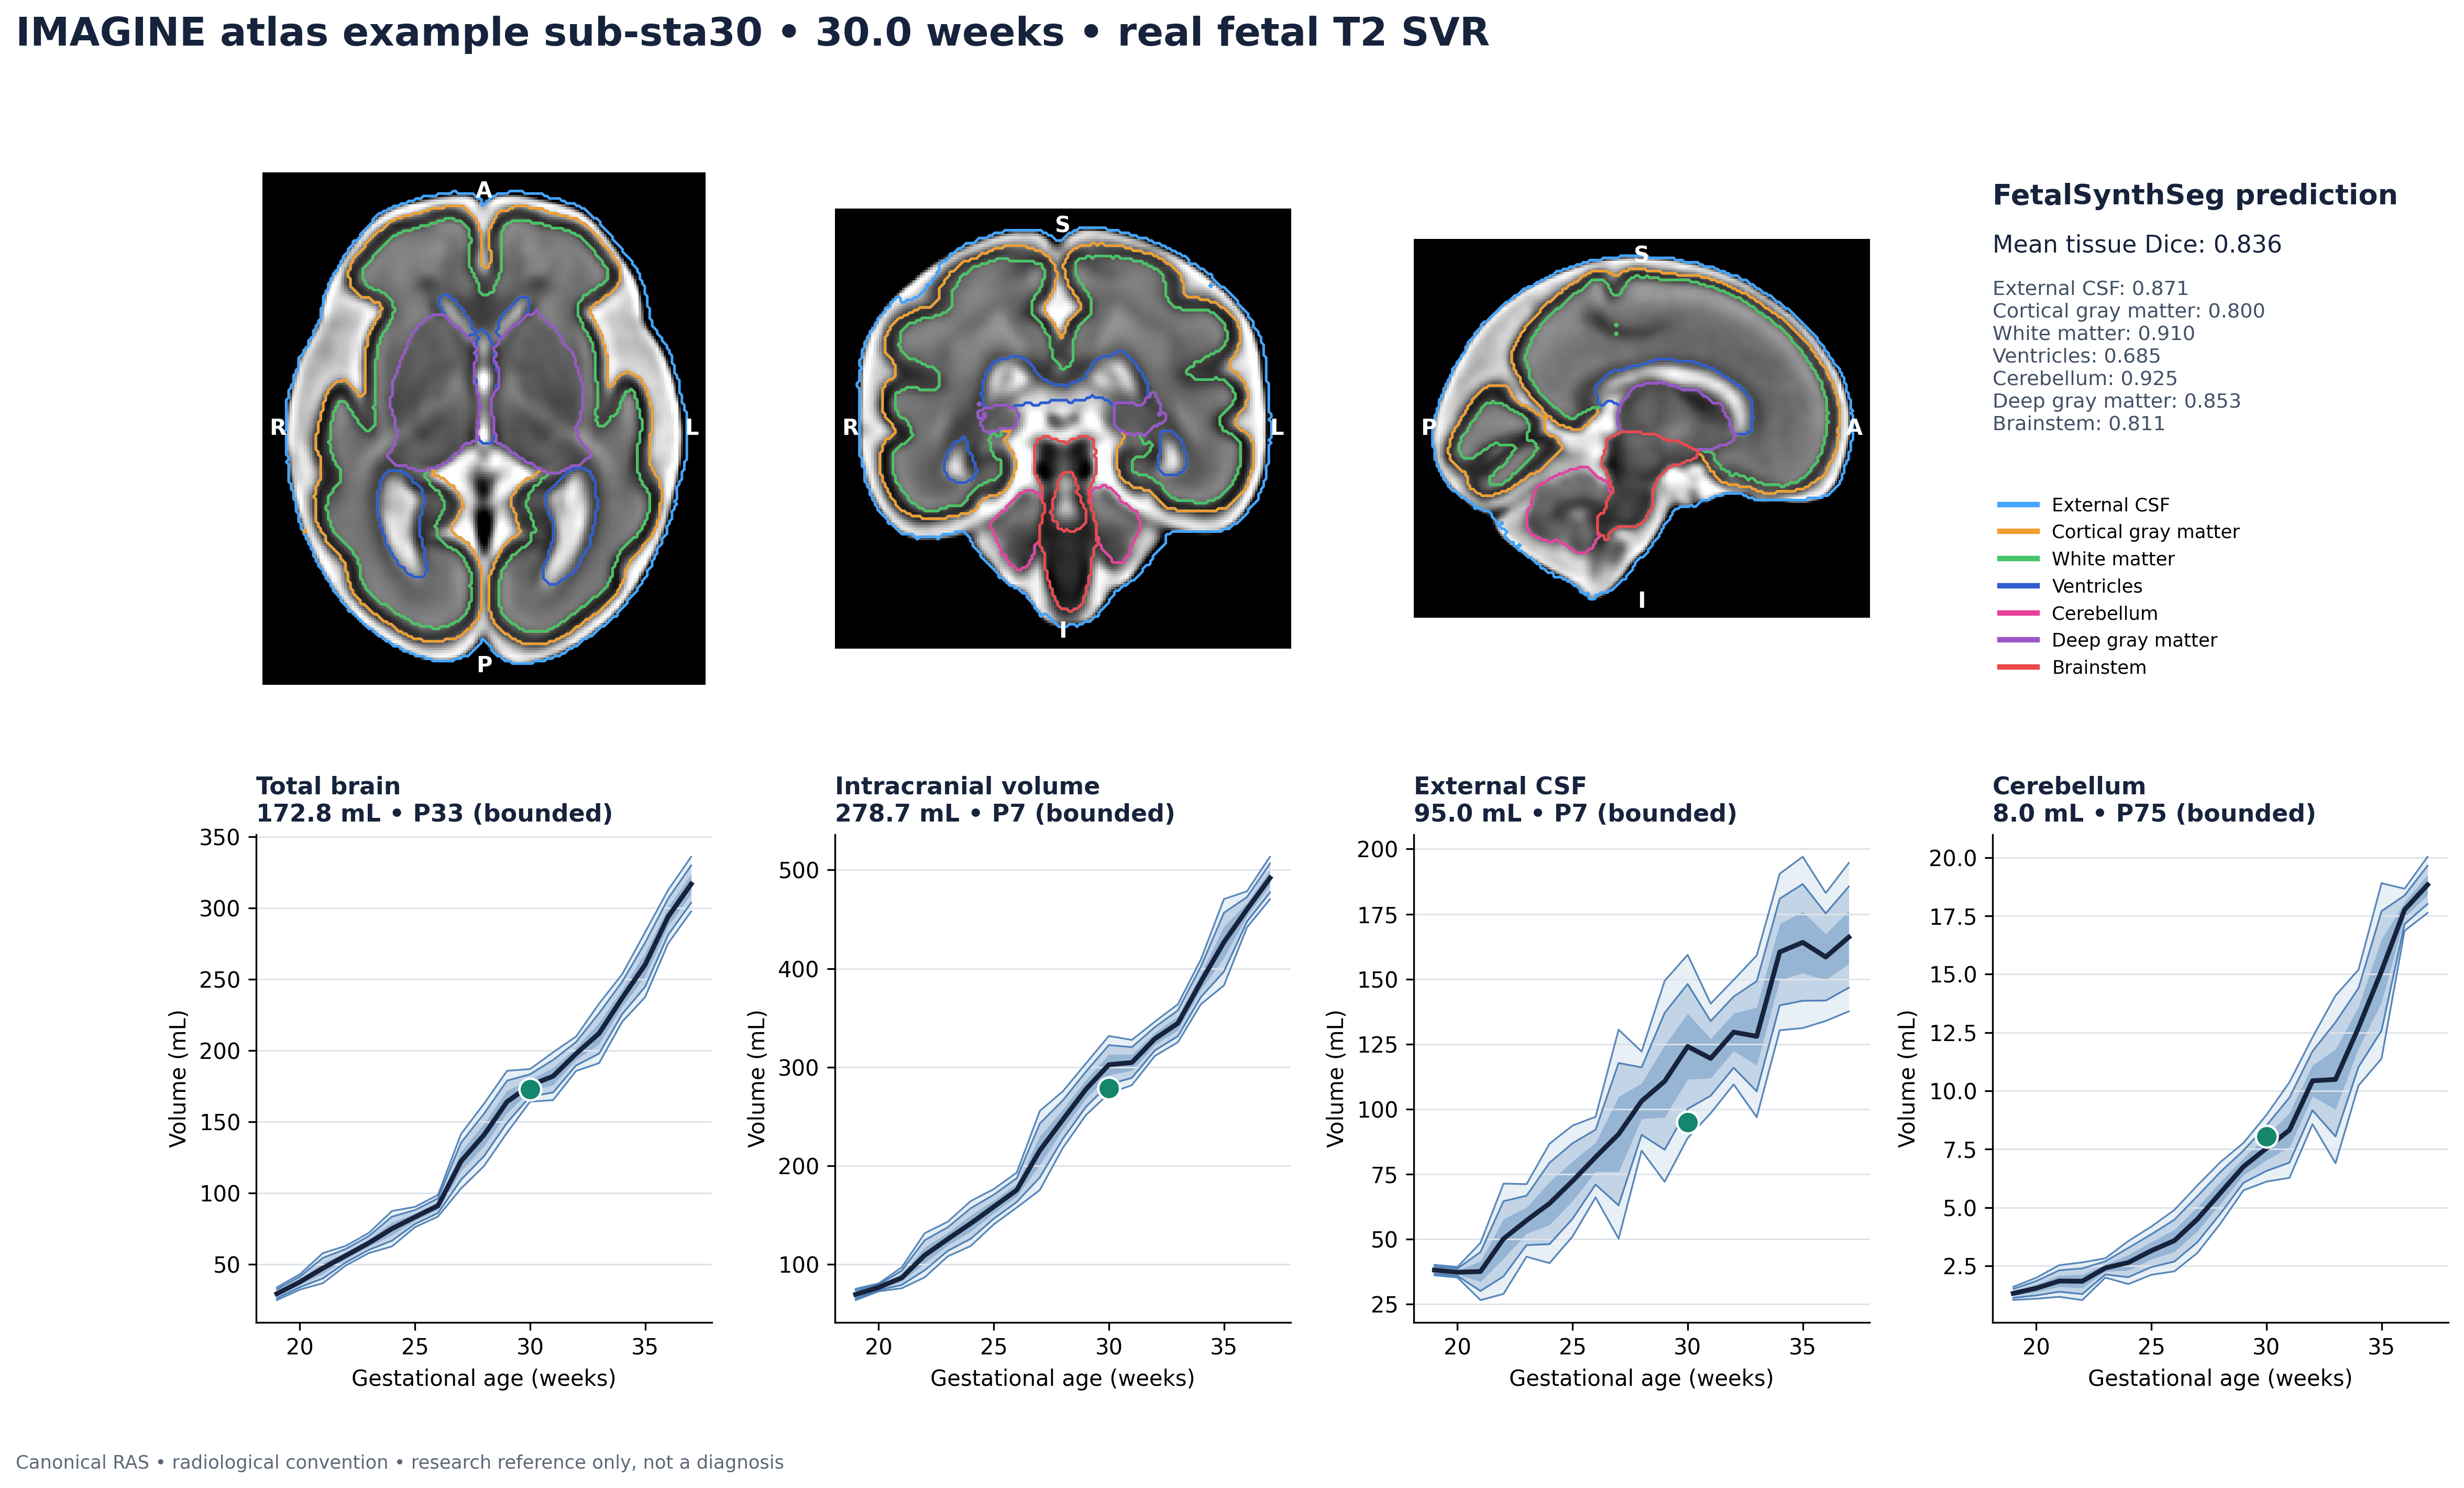

In [7]:
report = save_case_report(IMAGE_PATH, PREDICTED_PATH, curves, scores, OUT/'case_report.png', subject_id='IMAGINE atlas example sub-sta30', gestational_age_weeks=30.0, dice=dice)
display(Image(filename=str(report), width=1400))

## Interpretation and model choices

- A single scan is a cross-sectional position, not that fetus's longitudinal growth trajectory.
- A reference flag is not an abnormality diagnosis, and within-range volume does not exclude abnormal morphology.
- `interpolate` preserves published weekly means; `quadratic`, `cubic`, and leave-one-week-out `auto` are available.
- For all seven tissues, use the exact-label FeTA neurotypical teaching reference locally; prefer a larger reviewed cohort processed with the same frozen FetalSynthSeg model for validation.
- Review the complete 3-D MRI/segmentation and clinical context with a fetal neuroradiologist.